In [1]:
# ============================================================
# 7 : ADVANCED PIPELINE — GOLD NEXT-DAY RETURN PREDICTION (v2.1 Clean)
# ============================================================
# Pipeline:
# Step 1 : Feature Selection (Strictly Positive Permutation Importance)
# Step 2 : Hyperparameter Tuning (Optuna + TimeSeriesSplit)
# Step 3 : Weighted Average Ensemble (Inverse RMSE)
# Step 4 : Walk-Forward Validation (ใช้ best_params จาก Optuna)
# ============================================================
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
warnings.filterwarnings("ignore")

import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit

# ── reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ── Plot style
FIG_COLOR  = "#0D0D14"
ACCENT1    = "#00E5CC"
ACCENT2    = "#FF6B6B"
ACCENT3    = "#FFD166"
ACCENT4    = "#A78BFA"
GRID_COLOR = "#1E1E2E"
plt.style.use("dark_background")

# ============================================================
# 0 : LOAD SPLITS
# ============================================================
print("=" * 60)
print("0 : LOAD SPLITS")
print("=" * 60)

BASE = "../../../data/processed/splits/"

X_train = pd.read_csv(BASE + "X_train.csv", parse_dates=["Date"], index_col="Date")
X_val   = pd.read_csv(BASE + "X_val.csv",   parse_dates=["Date"], index_col="Date")
X_test  = pd.read_csv(BASE + "X_test.csv",  parse_dates=["Date"], index_col="Date")

y_train = pd.read_csv(BASE + "y_train_reg.csv", parse_dates=["Date"], index_col="Date").squeeze()
y_val   = pd.read_csv(BASE + "y_val_reg.csv",   parse_dates=["Date"], index_col="Date").squeeze()
y_test  = pd.read_csv(BASE + "y_test_reg.csv",  parse_dates=["Date"], index_col="Date").squeeze()

# รวม train+val สำหรับ Optuna / Walk-Forward
X_trainval = pd.concat([X_train, X_val])
y_trainval = pd.concat([y_train, y_val])

print(f"  X_train    : {X_train.shape}")
print(f"  X_val      : {X_val.shape}")
print(f"  X_test     : {X_test.shape}")
print(f"  X_trainval : {X_trainval.shape}")

# ============================================================
# HELPER — METRICS
# ============================================================
def evaluate(name, y_true, y_pred):
    rmse    = np.sqrt(mean_squared_error(y_true, y_pred))
    mae     = mean_absolute_error(y_true, y_pred)
    r2      = r2_score(y_true, y_pred)
    dir_acc = np.mean(np.sign(y_true) == np.sign(y_pred)) * 100
    print(f"  [{name}] RMSE={rmse:.4f}  MAE={mae:.4f}  R²={r2:.4f}  DirAcc={dir_acc:.1f}%")
    return {"rmse": rmse, "mae": mae, "r2": r2, "dir_acc": dir_acc}

# ============================================================
# STEP 1 : FEATURE SELECTION (Strict Permutation Importance)
# ============================================================
print("\n" + "=" * 60)
print("STEP 1 : FEATURE SELECTION — Strict Permutation Importance")
print("=" * 60)

# เทรน baseline LightGBM เร็วๆ เพื่อดู feature importance
_selector = lgb.LGBMRegressor(
    n_estimators=500, learning_rate=0.05, num_leaves=31,
    max_depth=5, min_child_samples=20, subsample=0.8,
    colsample_bytree=0.7, reg_alpha=0.1, reg_lambda=1.0,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
)
_selector.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(-1)],
)

# Permutation importance บน Validation set
rng = np.random.default_rng(RANDOM_STATE)
base_rmse = np.sqrt(mean_squared_error(y_val, _selector.predict(X_val)))

perm_scores = {}
for col in X_train.columns:
    X_permuted = X_val.copy()
    X_permuted[col] = rng.permutation(X_permuted[col].values)
    perm_rmse = np.sqrt(mean_squared_error(y_val, _selector.predict(X_permuted)))
    perm_scores[col] = perm_rmse - base_rmse  # บวก = สำคัญ, ลบ/ศูนย์ = ไม่สำคัญ

perm_series = pd.Series(perm_scores).sort_values(ascending=False)

# [FIX]: เลือกเฉพาะ features ที่ช่วยจริง (importance > 0) ไม่มี Fallback
selected_features = perm_series[perm_series > 0.0].index.tolist()

print(f"\n  Original features : {X_train.shape[1]}")
print(f"  Selected strictly positive features : {len(selected_features)}")
print(f"  Top 10 by importance:")
print(perm_series.head(10).to_string())

# Apply feature selection
X_train_fs    = X_train[selected_features]
X_val_fs      = X_val[selected_features]
X_test_fs     = X_test[selected_features]
X_trainval_fs = X_trainval[selected_features]

# ============================================================
# STEP 2 : HYPERPARAMETER TUNING (OPTUNA + TimeSeriesSplit)
# ============================================================
print("\n" + "=" * 60)
print("STEP 2 : HYPERPARAMETER TUNING — Optuna + TimeSeriesSplit")
print("=" * 60)

N_SPLITS = 5
N_TRIALS = 50
tscv = TimeSeriesSplit(n_splits=N_SPLITS, gap=1)

def lgb_objective(trial):
    params = {
        "n_estimators"     : trial.suggest_int("n_estimators", 200, 1500),
        "learning_rate"    : trial.suggest_float("learning_rate", 0.005, 0.1, log=True),
        "num_leaves"       : trial.suggest_int("num_leaves", 16, 127),
        "max_depth"        : trial.suggest_int("max_depth", 3, 8),
        "min_child_samples": trial.suggest_int("min_child_samples", 15, 100),
        "subsample"        : trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree" : trial.suggest_float("colsample_bytree", 0.4, 1.0),
        "reg_alpha"        : trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda"       : trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        "random_state"     : RANDOM_STATE,
        "n_jobs"           : -1,
        "verbose"          : -1,
    }
    cv_scores = []
    for train_idx, val_idx in tscv.split(X_trainval_fs):
        X_f_train = X_trainval_fs.iloc[train_idx]
        X_f_val   = X_trainval_fs.iloc[val_idx]
        y_f_train = y_trainval.iloc[train_idx]
        y_f_val   = y_trainval.iloc[val_idx]
        model = lgb.LGBMRegressor(**params)
        model.fit(
            X_f_train, y_f_train,
            eval_set=[(X_f_val, y_f_val)],
            callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(-1)],
        )
        pred = model.predict(X_f_val)
        cv_scores.append(np.sqrt(mean_squared_error(y_f_val, pred)))
    return np.mean(cv_scores)

def xgb_objective(trial):
    params = {
        "n_estimators"    : trial.suggest_int("n_estimators", 200, 1500),
        "learning_rate"   : trial.suggest_float("learning_rate", 0.005, 0.1, log=True),
        "max_depth"       : trial.suggest_int("max_depth", 3, 8),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 20),
        "subsample"       : trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.4, 1.0),
        "reg_alpha"       : trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda"      : trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        "gamma"           : trial.suggest_float("gamma", 0, 5),
        "random_state"    : RANDOM_STATE,
        "n_jobs"          : -1,
        "tree_method"     : "hist",
        "verbosity"       : 0,
    }
    cv_scores = []
    for train_idx, val_idx in tscv.split(X_trainval_fs):
        X_f_train = X_trainval_fs.iloc[train_idx]
        X_f_val   = X_trainval_fs.iloc[val_idx]
        y_f_train = y_trainval.iloc[train_idx]
        y_f_val   = y_trainval.iloc[val_idx]
        model = xgb.XGBRegressor(**params)
        model.fit(X_f_train, y_f_train, eval_set=[(X_f_val, y_f_val)], verbose=False)
        pred = model.predict(X_f_val)
        cv_scores.append(np.sqrt(mean_squared_error(y_f_val, pred)))
    return np.mean(cv_scores)

# ── Run Optuna — LightGBM
print(f"\n  [Optuna] LightGBM — {N_TRIALS} trials ...")
study_lgb = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_lgb.optimize(lgb_objective, n_trials=N_TRIALS, show_progress_bar=False)
best_lgb_params = study_lgb.best_params.copy()
best_lgb_params.update({"random_state": RANDOM_STATE, "n_jobs": -1, "verbose": -1})
print(f"  ✔ LightGBM best CV RMSE : {study_lgb.best_value:.4f}")

# ── Run Optuna — XGBoost
print(f"\n  [Optuna] XGBoost — {N_TRIALS} trials ...")
study_xgb = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_xgb.optimize(xgb_objective, n_trials=N_TRIALS, show_progress_bar=False)
best_xgb_params = study_xgb.best_params.copy()
best_xgb_params.update({"random_state": RANDOM_STATE, "n_jobs": -1, "tree_method": "hist", "verbosity": 0})
print(f"  ✔ XGBoost best CV RMSE : {study_xgb.best_value:.4f}")

# ── Retrain base models บน train → eval บน val
print("\n  Retraining base models with best hyperparameters ...")

tuned_lgb = lgb.LGBMRegressor(**best_lgb_params)
tuned_lgb.fit(X_train_fs, y_train, eval_set=[(X_val_fs, y_val)],
              callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)])

tuned_xgb = xgb.XGBRegressor(**best_xgb_params)
tuned_xgb.fit(X_train_fs, y_train, eval_set=[(X_val_fs, y_val)], verbose=False)

cat_params = {
    "iterations": 1000, "learning_rate": 0.03, "depth": 6, "l2_leaf_reg": 3.0,
    "min_data_in_leaf": 20, "subsample": 0.8, "random_seed": RANDOM_STATE,
    "verbose": 0, "early_stopping_rounds": 50, "eval_metric": "RMSE", "task_type": "CPU"
}
tuned_cat = CatBoostRegressor(**cat_params)
tuned_cat.fit(X_train_fs, y_train, eval_set=(X_val_fs, y_val), verbose=False)

print("\n  --- Tuned LightGBM ---")
m_lgb_val  = evaluate("Val ", y_val,  tuned_lgb.predict(X_val_fs))
m_lgb_test = evaluate("Test", y_test, tuned_lgb.predict(X_test_fs))

print("\n  --- Tuned XGBoost ---")
m_xgb_val  = evaluate("Val ", y_val,  tuned_xgb.predict(X_val_fs))
m_xgb_test = evaluate("Test", y_test, tuned_xgb.predict(X_test_fs))

print("\n  --- CatBoost ---")
m_cat_val  = evaluate("Val ", y_val,  tuned_cat.predict(X_val_fs))
m_cat_test = evaluate("Test", y_test, tuned_cat.predict(X_test_fs))

# ============================================================
# STEP 3 : WEIGHTED AVERAGE ENSEMBLE (Inverse RMSE)
# ============================================================
# [FIX]: เปลี่ยนจากการทำ Stacking กลับมาใช้ Weighted Avg เพื่อกัน Overfitting
print("\n" + "=" * 60)
print("STEP 3 : WEIGHTED AVERAGE ENSEMBLE (Inverse RMSE)")
print("=" * 60)

def rmse_weights(*rmse_values):
    inv   = [1.0 / r for r in rmse_values]
    total = sum(inv)
    return [w / total for w in inv]

w_lgb, w_xgb, w_cat = rmse_weights(m_lgb_val["rmse"], m_xgb_val["rmse"], m_cat_val["rmse"])

print(f"\n  Ensemble weights (Inverse RMSE on Val):")
print(f"    LightGBM : {w_lgb:.4f}")
print(f"    XGBoost  : {w_xgb:.4f}")
print(f"    CatBoost : {w_cat:.4f}")

pred_lgb_val  = tuned_lgb.predict(X_val_fs)
pred_xgb_val  = tuned_xgb.predict(X_val_fs)
pred_cat_val  = tuned_cat.predict(X_val_fs)

pred_lgb_test = tuned_lgb.predict(X_test_fs)
pred_xgb_test = tuned_xgb.predict(X_test_fs)
pred_cat_test = tuned_cat.predict(X_test_fs)

pred_ens_val  = w_lgb*pred_lgb_val + w_xgb*pred_xgb_val + w_cat*pred_cat_val
pred_ens_test = w_lgb*pred_lgb_test + w_xgb*pred_xgb_test + w_cat*pred_cat_test

print("\n  --- Weighted-Avg Ensemble (Val) ---")
m_ens_val  = evaluate("Val ", y_val,  pred_ens_val)
print("\n  --- Weighted-Avg Ensemble (Test) ---")
m_ens_test = evaluate("Test", y_test, pred_ens_test)

best_ens_name      = "WeightedAvg Ens"
best_pred_val_ens  = pred_ens_val
best_pred_test_ens = pred_ens_test
m_best_val         = m_ens_val
m_best_test        = m_ens_test

# ── Comparison table
comp_ensemble = pd.DataFrame({
    "Model"      : ["LightGBM", "XGBoost", "CatBoost", "WeightedAvg Ens"],
    "Val RMSE"   : [m_lgb_val["rmse"],   m_xgb_val["rmse"],   m_cat_val["rmse"],   m_ens_val["rmse"]],
    "Val DirAcc%": [m_lgb_val["dir_acc"],m_xgb_val["dir_acc"],m_cat_val["dir_acc"],m_ens_val["dir_acc"]],
    "Test RMSE"  : [m_lgb_test["rmse"],  m_xgb_test["rmse"],  m_cat_test["rmse"],  m_ens_test["rmse"]],
    "Test DirAcc%":[m_lgb_test["dir_acc"],m_xgb_test["dir_acc"],m_cat_test["dir_acc"],m_ens_test["dir_acc"]],
    "Test R²"    : [m_lgb_test["r2"],    m_xgb_test["r2"],    m_cat_test["r2"],    m_ens_test["r2"]],
})
print("\n  Ensemble Comparison:")
print(comp_ensemble.to_string(index=False))

# ============================================================
# STEP 4 : WALK-FORWARD VALIDATION
# ============================================================
print("\n" + "=" * 60)
print("STEP 4 : WALK-FORWARD VALIDATION (ใช้ best_lgb_params)")
print("=" * 60)

WF_INIT_TRAIN_ROWS = len(X_train)
WF_STEP            = 63   # ~1 quarter
X_wf = pd.concat([X_train_fs, X_val_fs, X_test_fs])
y_wf = pd.concat([y_train, y_val, y_test])

wf_params = best_lgb_params.copy()

wf_predictions  = []
wf_actuals      = []
wf_dates        = []
wf_fold_metrics = []

start_test = WF_INIT_TRAIN_ROWS
n_total    = len(X_wf)
fold       = 0

print(f"\n  Walk-forward config:")
print(f"    Initial train size : {WF_INIT_TRAIN_ROWS} rows")
print(f"    Step size          : {WF_STEP} rows")
print(f"    Total rows         : {n_total}")
print(f"    Using Optuna params: ✔")

while start_test < n_total:
    end_test    = min(start_test + WF_STEP, n_total)
    X_wf_train  = X_wf.iloc[:start_test]
    y_wf_train  = y_wf.iloc[:start_test]
    X_wf_chunk  = X_wf.iloc[start_test:end_test]
    y_wf_chunk  = y_wf.iloc[start_test:end_test]

    wf_model = lgb.LGBMRegressor(**wf_params)
    wf_model.fit(X_wf_train, y_wf_train, callbacks=[lgb.log_evaluation(-1)])

    chunk_pred = wf_model.predict(X_wf_chunk)
    chunk_rmse = np.sqrt(mean_squared_error(y_wf_chunk, chunk_pred))
    chunk_dir  = np.mean(np.sign(y_wf_chunk) == np.sign(chunk_pred)) * 100

    wf_predictions.extend(chunk_pred.tolist())
    wf_actuals.extend(y_wf_chunk.tolist())
    wf_dates.extend(y_wf_chunk.index.tolist())
    wf_fold_metrics.append({
        "fold"    : fold,
        "start"   : y_wf_chunk.index[0].date(),
        "end"     : y_wf_chunk.index[-1].date(),
        "n_rows"  : len(y_wf_chunk),
        "RMSE"    : chunk_rmse,
        "DirAcc%" : chunk_dir,
    })
    fold       += 1
    start_test  = end_test

wf_df = pd.DataFrame({
    "date"     : wf_dates,
    "actual"   : wf_actuals,
    "predicted": wf_predictions,
}).set_index("date")

wf_overall_rmse = np.sqrt(mean_squared_error(wf_df["actual"], wf_df["predicted"]))
wf_overall_dir  = np.mean(np.sign(wf_df["actual"]) == np.sign(wf_df["predicted"])) * 100
wf_overall_r2   = r2_score(wf_df["actual"], wf_df["predicted"])

print(f"\n  Walk-forward fold results:")
fold_df = pd.DataFrame(wf_fold_metrics)
print(fold_df.to_string(index=False))

print(f"\n  Walk-Forward Overall:")
print(f"    RMSE   = {wf_overall_rmse:.4f}")
print(f"    DirAcc = {wf_overall_dir:.1f}%")
print(f"    R²     = {wf_overall_r2:.4f}")

0 : LOAD SPLITS
  X_train    : (1479, 69)
  X_val      : (501, 69)
  X_test     : (563, 69)
  X_trainval : (1980, 69)

STEP 1 : FEATURE SELECTION — Strict Permutation Importance

  Original features : 69
  Selected strictly positive features : 5
  Top 10 by importance:
f_corr_90d_oil          0.000161
f_gold_ma_cross_5_20    0.000150
f_gold_body_pct         0.000127
f_gold_dist_ma10        0.000119
f_real_rate_chg_1m      0.000086
f_gold_close_ret        0.000000
f_month                 0.000000
f_rollover_flag         0.000000
f_is_month_end          0.000000
f_quarter               0.000000

STEP 2 : HYPERPARAMETER TUNING — Optuna + TimeSeriesSplit

  [Optuna] LightGBM — 50 trials ...
  ✔ LightGBM best CV RMSE : 0.7109

  [Optuna] XGBoost — 50 trials ...
  ✔ XGBoost best CV RMSE : 0.7122

  Retraining base models with best hyperparameters ...

  --- Tuned LightGBM ---
  [Val ] RMSE=0.7615  MAE=0.5848  R²=0.0073  DirAcc=51.7%
  [Test] RMSE=0.8434  MAE=0.6587  R²=-0.0629  DirAcc=45.3%



STEP 5: VISUALIZATION


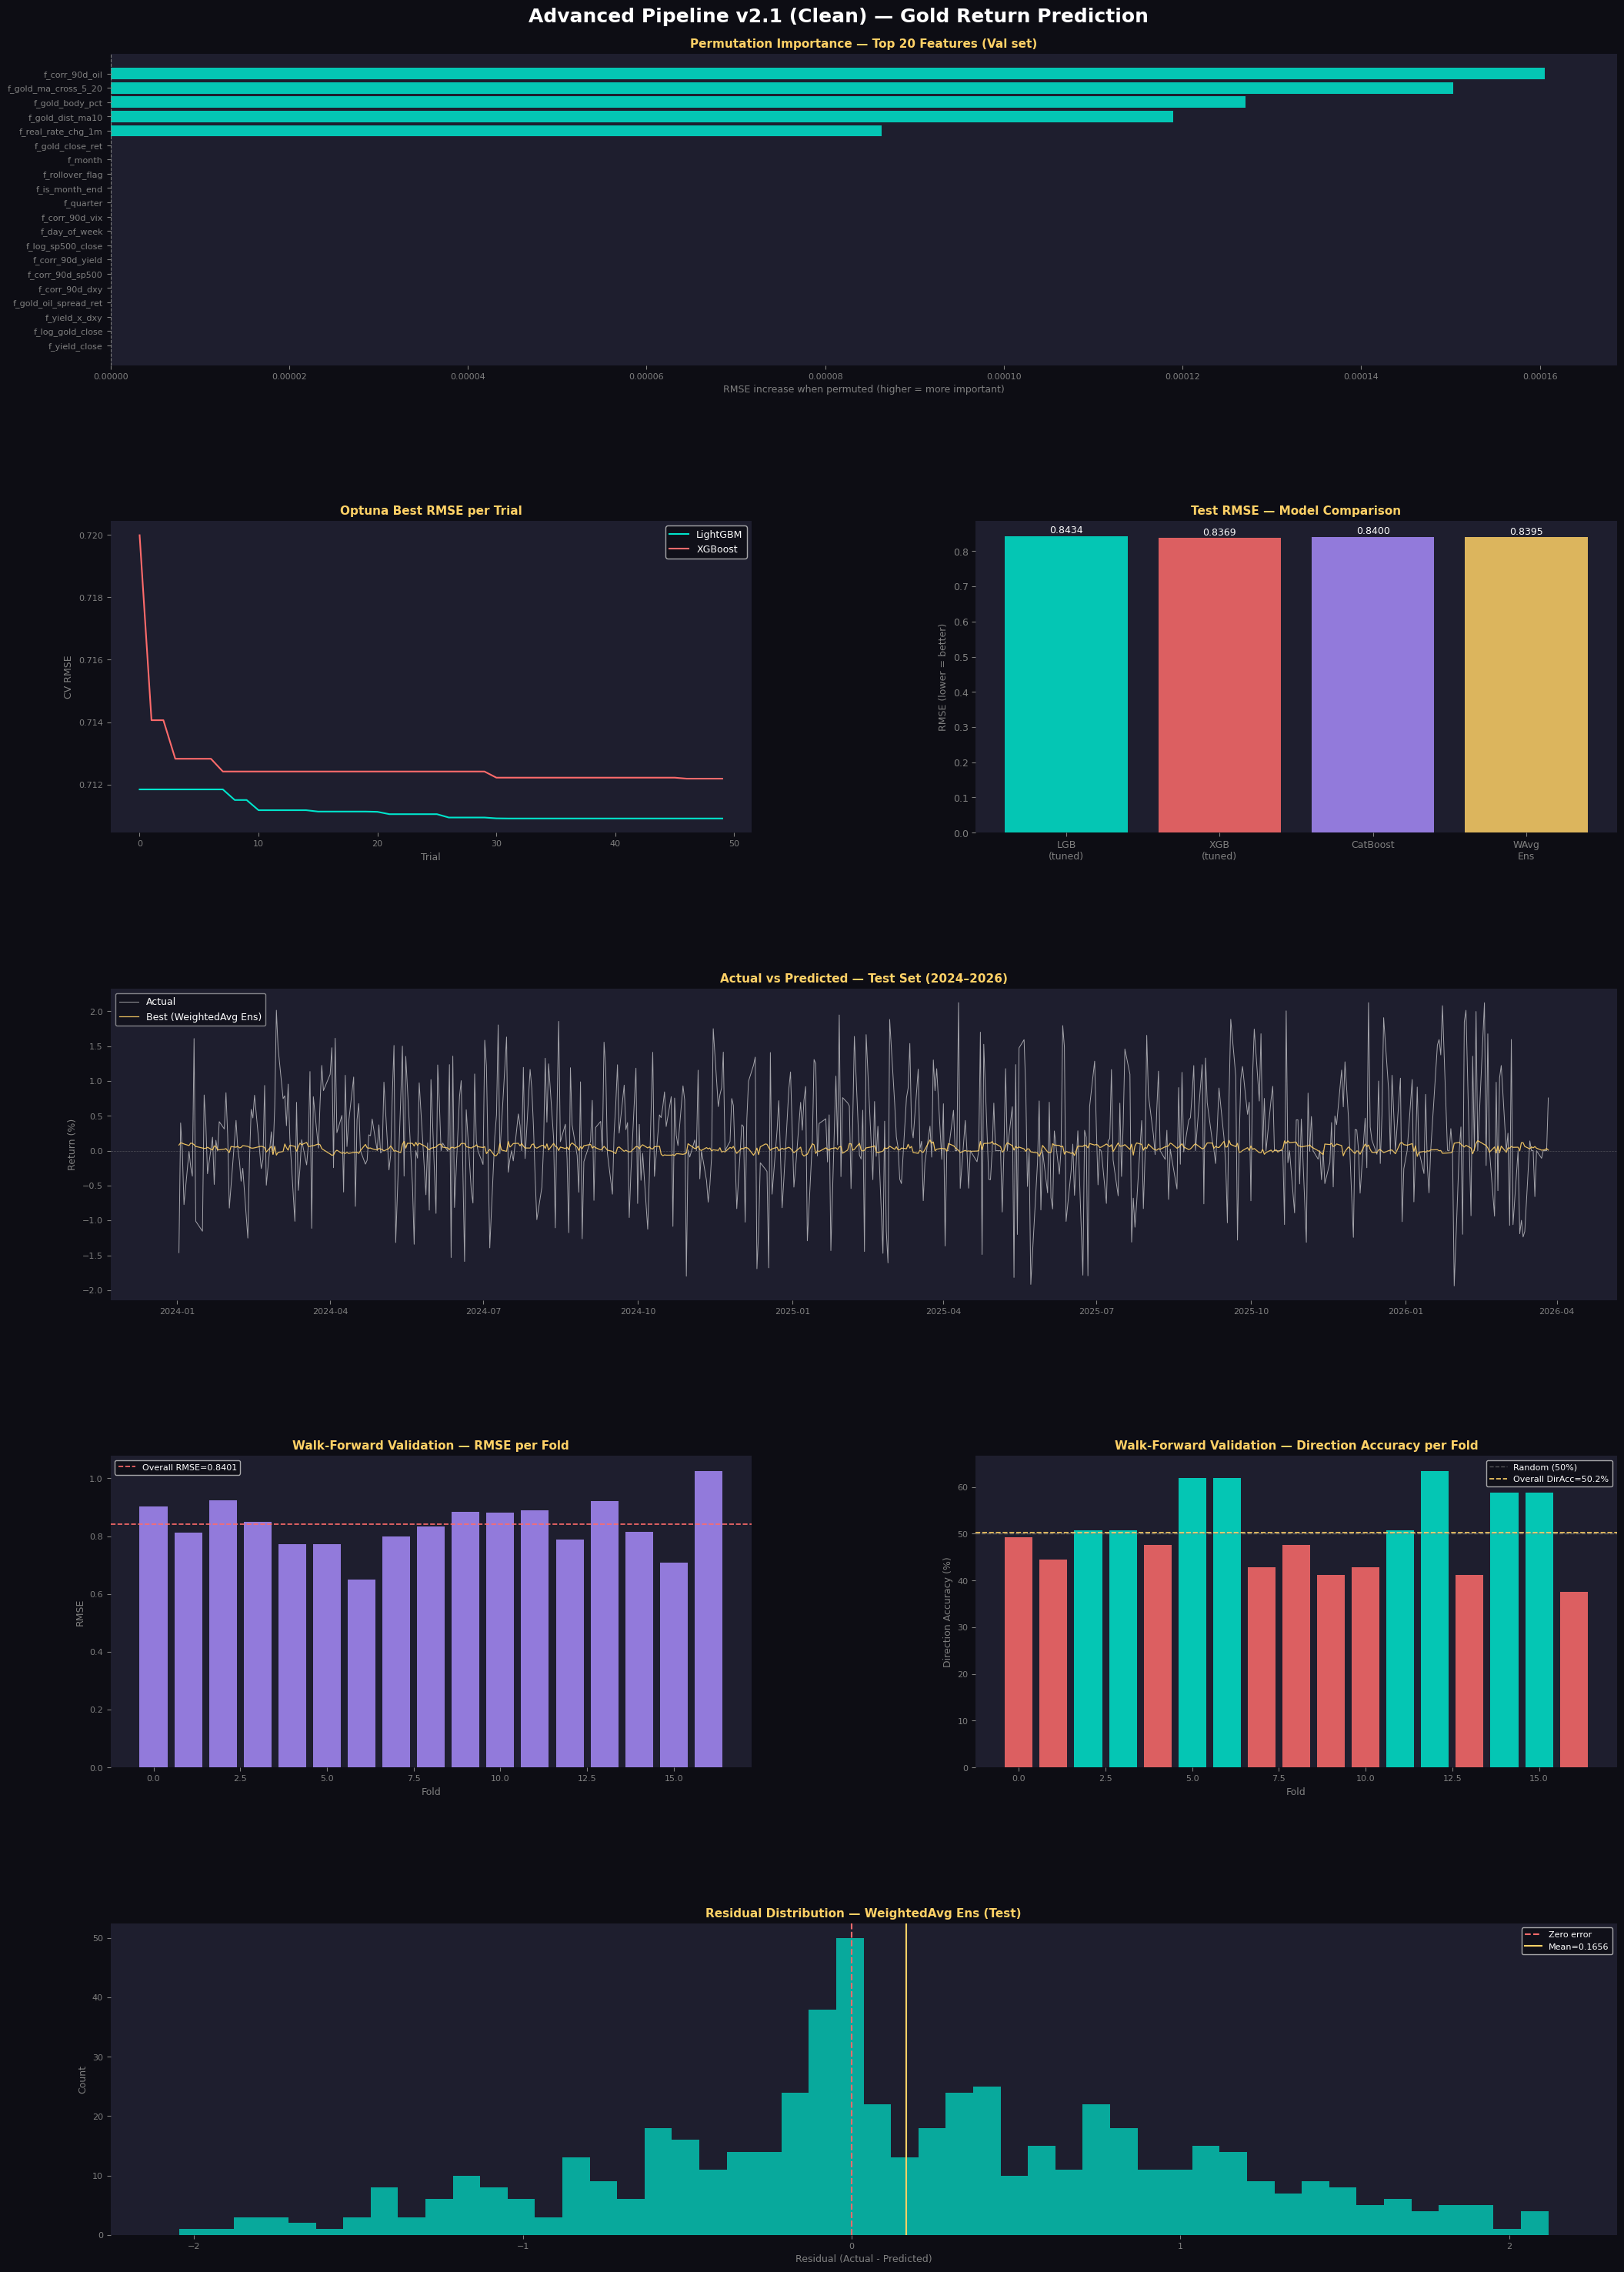

In [3]:
# ============================================================
# STEP 5 : VISUALIZATION
# ============================================================
print("\n" + "=" * 60)
print("STEP 5: VISUALIZATION")
print("=" * 60)

fig = plt.figure(figsize=(22, 30), facecolor=FIG_COLOR)
fig.suptitle("Advanced Pipeline v2.1 (Clean) — Gold Return Prediction", 
             fontsize=18, color="white", fontweight="bold", y=0.995)

gs = gridspec.GridSpec(5, 2, figure=fig, hspace=0.5, wspace=0.35, 
                       left=0.07, right=0.96, top=0.975, bottom=0.03)

# ── Panel 1: Feature Importance (top 20)
ax0 = fig.add_subplot(gs[0, :])
ax0.set_facecolor(GRID_COLOR)
top_feat = perm_series.head(20)
colors_feat = [ACCENT1 if v > 0 else ACCENT2 for v in top_feat.values]
ax0.barh(range(len(top_feat)), top_feat.values[::-1], color=colors_feat[::-1], alpha=0.85, edgecolor="none")
ax0.set_yticks(range(len(top_feat)))
ax0.set_yticklabels(top_feat.index[::-1], fontsize=8, color="white")
ax0.axvline(0, color="gray", lw=0.8, linestyle="--")
ax0.set_title("Permutation Importance — Top 20 Features (Val set)", color=ACCENT3, fontsize=11, fontweight="bold")
ax0.set_xlabel("RMSE increase when permuted (higher = more important)", color="gray", fontsize=9)
ax0.tick_params(colors="gray", labelsize=8)
ax0.spines[:].set_visible(False)

# ── Panel 2: Optuna History
ax1 = fig.add_subplot(gs[1, 0])
ax1.set_facecolor(GRID_COLOR)
lgb_values = [t.value for t in study_lgb.trials]
xgb_values = [t.value for t in study_xgb.trials]
ax1.plot(np.minimum.accumulate(lgb_values), color=ACCENT1, lw=1.5, label="LightGBM")
ax1.plot(np.minimum.accumulate(xgb_values), color=ACCENT2, lw=1.5, label="XGBoost")
ax1.set_title("Optuna Best RMSE per Trial", color=ACCENT3, fontsize=11, fontweight="bold")
ax1.set_xlabel("Trial", color="gray", fontsize=9)
ax1.set_ylabel("CV RMSE", color="gray", fontsize=9)
ax1.legend(fontsize=9, facecolor=FIG_COLOR, labelcolor="white")
ax1.tick_params(colors="gray", labelsize=8)
ax1.spines[:].set_visible(False)

# ── [FIX] Panel 3: Model Comparison Bar (Update without Stacking)
ax2 = fig.add_subplot(gs[1, 1])
ax2.set_facecolor(GRID_COLOR)
model_names = ["LGB\n(tuned)", "XGB\n(tuned)", "CatBoost", "WAvg\nEns"]
test_rmses = [m_lgb_test["rmse"], m_xgb_test["rmse"], m_cat_test["rmse"], m_ens_test["rmse"]]
colors_bar = [ACCENT1, ACCENT2, ACCENT4, ACCENT3]
bars = ax2.bar(model_names, test_rmses, color=colors_bar, alpha=0.85, edgecolor="none")
for bar, val in zip(bars, test_rmses):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 0.002, f"{val:.4f}",
             ha="center", va="bottom", color="white", fontsize=9)
ax2.set_title("Test RMSE — Model Comparison", color=ACCENT3, fontsize=11, fontweight="bold")
ax2.set_ylabel("RMSE (lower = better)", color="gray", fontsize=9)
ax2.tick_params(colors="gray", labelsize=9)
ax2.spines[:].set_visible(False)

# ── Panel 4: Actual vs Predicted Test
ax3 = fig.add_subplot(gs[2, :])
ax3.set_facecolor(GRID_COLOR)
ax3.plot(X_test_fs.index, y_test.values, color="white", lw=0.7, alpha=0.6, label="Actual")
ax3.plot(X_test_fs.index, best_pred_test_ens, color=ACCENT3, lw=0.9, alpha=0.9, label=f"Best ({best_ens_name})")
ax3.axhline(0, color="gray", linestyle="--", lw=0.5, alpha=0.5)
ax3.set_title("Actual vs Predicted — Test Set (2024–2026)", color=ACCENT3, fontsize=11, fontweight="bold")
ax3.set_ylabel("Return (%)", color="gray", fontsize=9)
ax3.legend(fontsize=9, facecolor=FIG_COLOR, labelcolor="white", framealpha=0.6)
ax3.tick_params(colors="gray", labelsize=8)
ax3.spines[:].set_visible(False)
ax3.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%Y-%m"))

# ── Panel 5: Walk-Forward RMSE per fold
ax4 = fig.add_subplot(gs[3, 0])
ax4.set_facecolor(GRID_COLOR)
ax4.bar(range(len(wf_fold_metrics)), [f["RMSE"] for f in wf_fold_metrics], color=ACCENT4, alpha=0.85, edgecolor="none")
ax4.axhline(wf_overall_rmse, color=ACCENT2, linestyle="--", lw=1.2, label=f"Overall RMSE={wf_overall_rmse:.4f}")
ax4.set_title("Walk-Forward Validation — RMSE per Fold", color=ACCENT3, fontsize=11, fontweight="bold")
ax4.set_xlabel("Fold", color="gray", fontsize=9)
ax4.set_ylabel("RMSE", color="gray", fontsize=9)
ax4.legend(fontsize=8, facecolor=FIG_COLOR, labelcolor="white")
ax4.tick_params(colors="gray", labelsize=8)
ax4.spines[:].set_visible(False)

# ── Panel 6: Walk-Forward DirAcc per fold
ax5 = fig.add_subplot(gs[3, 1])
ax5.set_facecolor(GRID_COLOR)
dir_accs = [f["DirAcc%"] for f in wf_fold_metrics]
colors_wf = [ACCENT1 if d > 50 else ACCENT2 for d in dir_accs]
ax5.bar(range(len(wf_fold_metrics)), dir_accs, color=colors_wf, alpha=0.85, edgecolor="none")
ax5.axhline(50, color="gray", linestyle="--", lw=1.0, alpha=0.6, label="Random (50%)")
ax5.axhline(wf_overall_dir, color=ACCENT3, linestyle="--", lw=1.2, label=f"Overall DirAcc={wf_overall_dir:.1f}%")
ax5.set_title("Walk-Forward Validation — Direction Accuracy per Fold", color=ACCENT3, fontsize=11, fontweight="bold")
ax5.set_xlabel("Fold", color="gray", fontsize=9)
ax5.set_ylabel("Direction Accuracy (%)", color="gray", fontsize=9)
ax5.legend(fontsize=8, facecolor=FIG_COLOR, labelcolor="white")
ax5.tick_params(colors="gray", labelsize=8)
ax5.spines[:].set_visible(False)

# ── Panel 7: Residual distribution
ax6 = fig.add_subplot(gs[4, :])
ax6.set_facecolor(GRID_COLOR)
residuals = y_test.values - best_pred_test_ens
ax6.hist(residuals, bins=50, color=ACCENT1, alpha=0.7, edgecolor="none")
ax6.axvline(0, color=ACCENT2, lw=1.5, linestyle="--", label="Zero error")
ax6.axvline(np.mean(residuals), color=ACCENT3, lw=1.5, linestyle="-", label=f"Mean={np.mean(residuals):.4f}")
ax6.set_title(f"Residual Distribution — {best_ens_name} (Test)", color=ACCENT3, fontsize=11, fontweight="bold")
ax6.set_xlabel("Residual (Actual - Predicted)", color="gray", fontsize=9)
ax6.set_ylabel("Count", color="gray", fontsize=9)
ax6.legend(fontsize=8, facecolor=FIG_COLOR, labelcolor="white")
ax6.tick_params(colors="gray", labelsize=8)
ax6.spines[:].set_visible(False)

# plt.savefig(BASE + "7_advanced_pipeline_v2_clean.png", dpi=140, bbox_inches="tight", facecolor=FIG_COLOR)
# print("  ✔ Saved visualization → 7_advanced_pipeline_v2_clean.png")
plt.show()

In [4]:
# ============================================================
# FINAL SUMMARY
# ============================================================
print("\n" + "=" * 60)
print("FINAL SUMMARY")
print("=" * 60)
print(f"""
  STEP 1 — FEATURE SELECTION (Strict)
    Original features : {X_train.shape[1]:<6}
    Selected features : {len(selected_features):<6}  (Only Importance > 0)

  STEP 2 — HYPERPARAMETER TUNING (Optuna, {N_TRIALS} trials)
    LightGBM best CV RMSE: {study_lgb.best_value:.4f}
    XGBoost  best CV RMSE: {study_xgb.best_value:.4f}

  STEP 3 — WEIGHTED AVERAGE ENSEMBLE
    Test RMSE    : {m_best_test['rmse']:.4f}
    Test DirAcc  : {m_best_test['dir_acc']:.1f}%
    Test R²      : {m_best_test['r2']:.4f}

  STEP 4 — WALK-FORWARD VALIDATION (Optuna params)
    Overall RMSE : {wf_overall_rmse:.4f}
    Overall Dir  : {wf_overall_dir:.1f}%
    Overall R²   : {wf_overall_r2:.4f}
""")


FINAL SUMMARY

  STEP 1 — FEATURE SELECTION (Strict)
    Original features : 69    
    Selected features : 5       (Only Importance > 0)

  STEP 2 — HYPERPARAMETER TUNING (Optuna, 50 trials)
    LightGBM best CV RMSE: 0.7109
    XGBoost  best CV RMSE: 0.7122

  STEP 3 — WEIGHTED AVERAGE ENSEMBLE
    Test RMSE    : 0.8395
    Test DirAcc  : 47.6%
    Test R²      : -0.0531

  STEP 4 — WALK-FORWARD VALIDATION (Optuna params)
    Overall RMSE : 0.8401
    Overall Dir  : 50.2%
    Overall R²   : -0.1076



In [5]:
# ============================================================
# EXPORT REGRESSION PREDICTIONS FOR BACKTEST
# ============================================================
import os

print("\n" + "=" * 60)
print("EXPORTING REGRESSION PREDICTIONS")
print("=" * 60)

# สร้างโฟลเดอร์สำหรับเก็บไฟล์ (ถ้ายังไม่มี)
SAVE_DIR = "../../../data/processed/predictions"
os.makedirs(SAVE_DIR, exist_ok=True)

# สร้าง DataFrame เก็บผลทำนายของ Test Set
# ใช้ X_test_fs.index เพื่อให้มีคอลัมน์ Date สำหรับไป Merge กับ Classification
reg_output_df = pd.DataFrame({
    "actual_return": y_test.values,
    "pred_return": best_pred_test_ens  # ผลทำนายจาก WeightedAvg Ensemble
}, index=X_test_fs.index)

# ตั้งชื่อ Index ให้ชัดเจน
reg_output_df.index.name = "Date"

# บันทึกไฟล์ CSV
save_path = f"{SAVE_DIR}/reg_predictions_v2_clean.csv"
reg_output_df.to_csv(save_path)

print(f"  Saved Regression predictions to: {save_path}")
print(f"  Total rows: {len(reg_output_df)}")
print("\n  Sample Data (first 5 rows):")
print(reg_output_df.head().to_string())


EXPORTING REGRESSION PREDICTIONS
  Saved Regression predictions to: ../../../data/processed/predictions/reg_predictions_v2_clean.csv
  Total rows: 563

  Sample Data (first 5 rows):
            actual_return  pred_return
Date                                  
2024-01-02      -1.462892     0.081149
2024-01-03       0.398196     0.111390
2024-01-04       0.004895     0.106679
2024-01-05      -0.773602     0.096283
2024-01-08      -0.009866     0.073640


In [6]:
print(best_lgb_params)

{'n_estimators': 725, 'learning_rate': 0.06617596968048838, 'num_leaves': 27, 'max_depth': 6, 'min_child_samples': 93, 'subsample': 0.9589199546789873, 'colsample_bytree': 0.657274777063807, 'reg_alpha': 0.004439653780309992, 'reg_lambda': 0.060009792539478475, 'random_state': 42, 'n_jobs': -1, 'verbose': -1}


In [7]:
print(selected_features)

['f_corr_90d_oil', 'f_gold_ma_cross_5_20', 'f_gold_body_pct', 'f_gold_dist_ma10', 'f_real_rate_chg_1m']
